# Networks and Graphs

Real-world systems that can be understood as networks or graphs:

**Information Technology Networks**: These include the internet, telephone networks, and local computer networks.
- each node represents a device or server, and each edge is a communication link.

**Transportation Networks**: The systems that connect locations, like road networks, railway networks, waterways, and even networks for utilities like water, gas, and electricity.
- nodes could represent stations, intersections, or locations, and edges the routes or pathways between them.

**Social Networks**: includes networks of friendships, relationships, professional contacts, memberships in clubs or organizations, and more.
- nodes represent individuals or entities, and edges represent relationships or interactions between them.

**Biological Networks**: Within biology, networks can represent protein interactions, gene regulation, neural connections, food webs, and much more.
- Nodes could be anything from individual organisms to specific genes, with edges indicating different types of biological interaction.



## Graph Terms

Networks or graphs consist of two different types of elements: nodes and edges.

- **Nodes (or vertices)**
- **Edges (or links, connections):**  
  - directed or undirected
  - weighted or unweighted

<img src = 'https://drive.google.com/uc?id=1FxVvMdOoo1hAzNqpO9cyLbLkCDZREayN' width=800 >



## Graph Terms

The **degree $k$** of a node is the number of links or connections it has.
- For directed graphs, we distinguish between in-degree and out-degree

<img src = 'https://drive.google.com/uc?id=1y_M1eTr3ugbmIAEziMcPiTdc8Pp_lATV' width=800 >



## NetworkX

NetworkX is a great graph package in Python
- [documentation](https://networkx.org/documentation/stable/reference/index.html)
- [tutorial](https://networkx.org/documentation/stable/tutorial.html)
- install with `!pip install networkx` if not using Colab
- commonly import as `nx`

## Creating Graph Objects

- Undirected graphs: initiate with `nx.Graph()`
- Directed graphs: initiate with `nx.DiGraph()`

- **Nodes** can be added:
  - individually with `.add_node(...)`
  - many nodes at once with `.add_nodes_from(...)`

- **Edges** can be added:
  - individually with `.add_edge(...)`
  - many nodes at once with `.add_edges_from(...)`

In [3]:
# Example Graph
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import networkx as nx


# Initiate a graph
G = nx.Graph()
print(G)




Graph with 0 nodes and 0 edges


In [3]:
# Example Graph
# add a single node
G.add_node("Alice")

# add all nodes from a list
G.add_nodes_from(["Bobby", "Caden", "Dylan", "Emily"])

# get the nodes
print(G.nodes)



['Alice', 'Bobby', 'Caden', 'Dylan', 'Emily']


In [4]:
# Example Graph
# add single edge
G.add_edge("Alice", "Bobby")

# add edges from a list
G.add_edges_from([("Bobby", "Dylan"),
                  ("Dylan", "Emily"),
                  ("Dylan", "Caden"),
                  ("Caden", "Emily"),
                  ("Emily", "Bobby"),
                 ])
# get the edges
print(G.edges)

[('Alice', 'Bobby'), ('Bobby', 'Dylan'), ('Bobby', 'Emily'), ('Caden', 'Dylan'), ('Caden', 'Emily'), ('Dylan', 'Emily')]


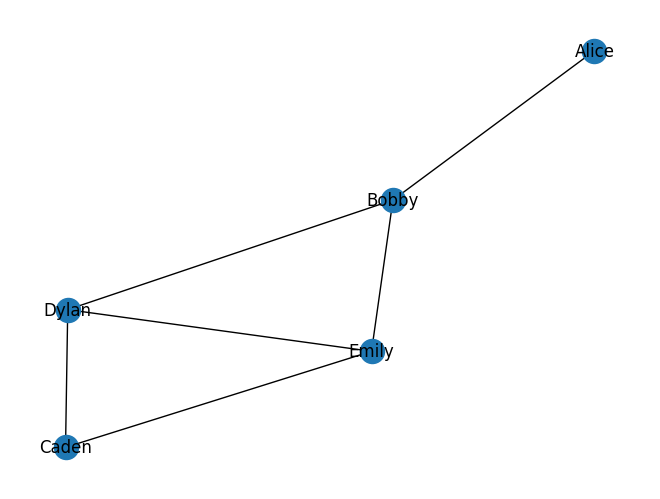

In [5]:
# Quick Graph Visualization

nx.draw(G, with_labels=True)

In [6]:
# Degree

print(G.degree)

[('Alice', 1), ('Bobby', 3), ('Caden', 2), ('Dylan', 3), ('Emily', 3)]


## Graph Metrics

- **$L_{max}$: maximum possible number of edges**  
  - every node is connected to every other node
  - every pair of distinct vertices is connected by a unique edge.
  For a network with $N$ nodes, the maximum possible number of edges is: $$ L_{max}=\frac{N(N−1)}{2} $$
- **$d$: density** $$d = L/L_{max} = \frac{2L}{N(N-1)}$$
  - range between 0 (sparse) and 1 (dense)
- **$\langle k \rangle$: average degree**
  - mean number of edges per node $$\langle k \rangle = \frac{\sum	_i k_i}{N}$$
  - degree can then be expressed as $$d = \frac{\langle k \rangle}{N-1}$$

In [7]:
# Using networkx

print(f"Number of nodes = {G.number_of_nodes()}")
print(f"Number of edges = {G.number_of_edges()}")
print(f"Maximum possible number of edges = {G.number_of_nodes() * (G.number_of_nodes() - 1) / 2}")
print(f"Density = {nx.density(G)}")
print(f"Average degree = {2 * G.number_of_edges() / G.number_of_nodes()}")

Number of nodes = 5
Number of edges = 6
Maximum possible number of edges = 10.0
Density = 0.6
Average degree = 2.4


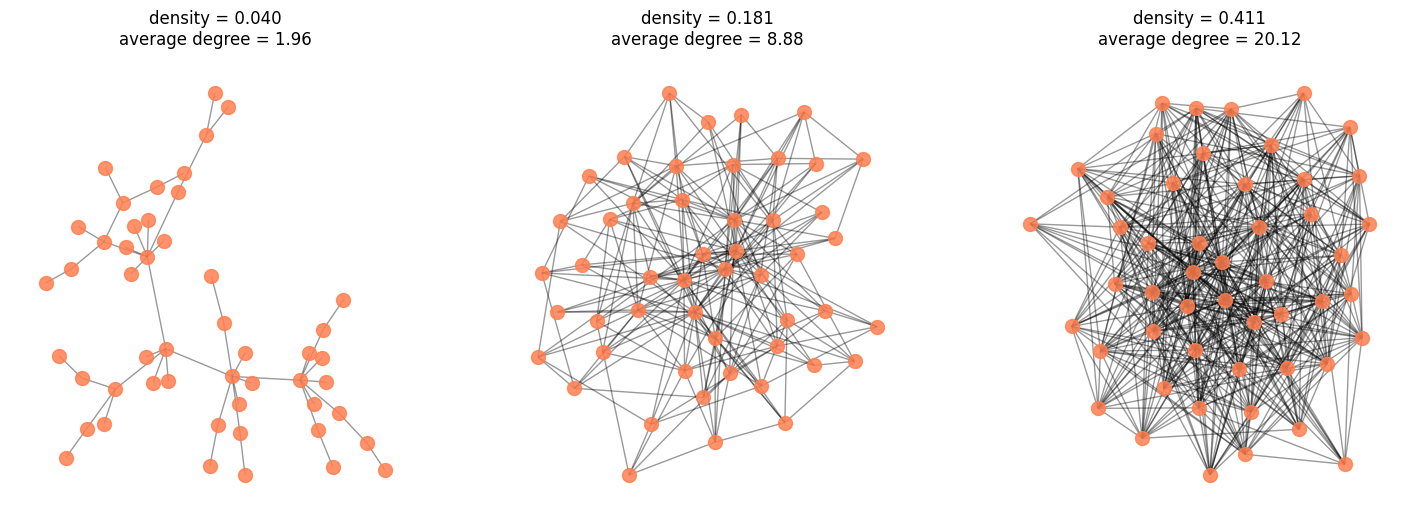

In [9]:
# Example from Florian text
num_nodes = 50
plot_parameters = {"node_size": 100,
                   "node_color": "coral",
                   "alpha": 0.85
                  }

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), dpi=100)

# 1
G = nx.powerlaw_cluster_graph(num_nodes, 1, 0.2, seed=0)
pos = nx.spring_layout(G, k=0.1, seed=0)
nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax1)
nodes1 = nx.draw_networkx_nodes(G, pos,
                                **plot_parameters,
                                ax=ax1,
                                )
ax1.set_title(f"density = {nx.density(G):.3f}" + \
              f"\naverage degree = {np.mean([x[1] for x in G.degree])}"
             )

# 2
G = nx.powerlaw_cluster_graph(num_nodes, 5, 0.2, seed=0)
pos = nx.spring_layout(G, k=0.1, seed=0)
nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax2)
nodes1 = nx.draw_networkx_nodes(G, pos,
                                **plot_parameters,
                                ax=ax2,
                                )
ax2.set_title(f"density = {nx.density(G):.3f}" + \
              f"\naverage degree = {np.mean([x[1] for x in G.degree])}"
             )

# 3
G = nx.powerlaw_cluster_graph(num_nodes, 15, 0.2, seed=0)
pos = nx.spring_layout(G, k=0.1, seed=0)
nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax3)
nodes1 = nx.draw_networkx_nodes(G, pos,
                                **plot_parameters,
                                ax=ax3,
                                )
ax3.set_title(f"density = {nx.density(G):.3f}" + \
              f"\naverage degree = {np.mean([x[1] for x in G.degree])}"
             )

ax1.axis('off')
ax2.axis("off")
ax3.axis("off")
plt.show()

## Connected and Unconnected

- Connected graphs: there is a path between any two nodes
- Unconnected graphs: at least one node is not connected to every other node



False

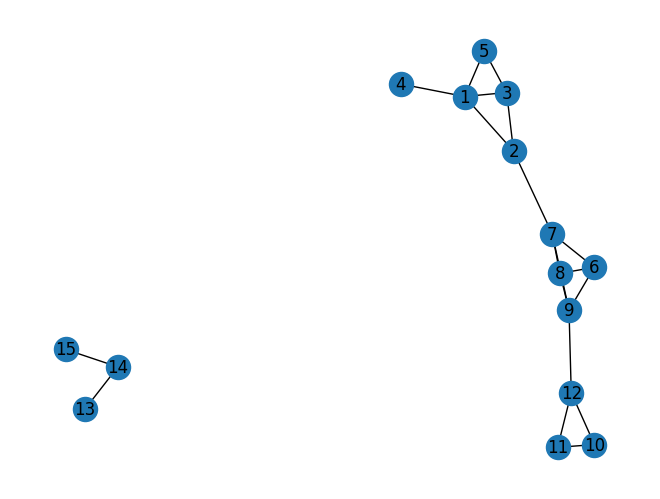

In [11]:
#Unconnected example
G = nx.Graph()
G.add_edges_from([[1,2], [2,3], [1,3], [1,4], [1,5], [3,5],
                  [6,7], [7,8], [8,9], [6,9], [6,8], [7,9],
                  [10,11], [11,12], [10,12], [9,12], [2,7],
                  [13, 14], [14, 15]])
nx.draw(G, with_labels=True)
nx.is_connected(G)

## Directed Graphs

Edges have a *direction* from one node to another node

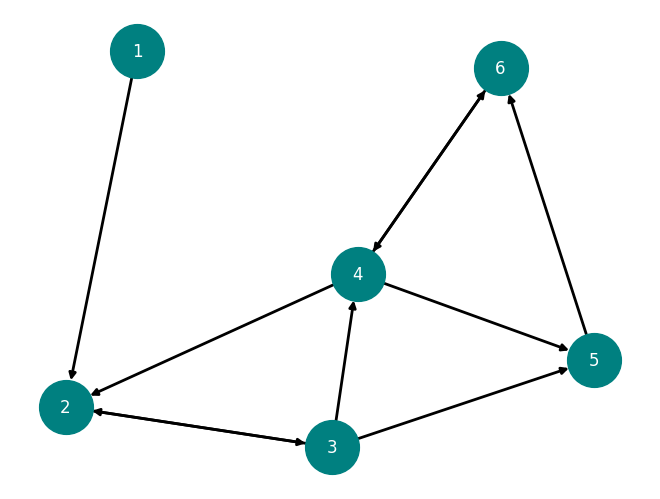

In [13]:
## Directed example
D = nx.DiGraph()
D.add_edges_from([
    (1,2), (2,3),
    (3,2), (3,4),
    (3,5), (4,2),
    (4,5), (4,6),
    (5,6), (6,4),
])
nx.draw(D, with_labels=True,
       node_color='teal',
       node_size=1500,
       font_color='white',
       width=2)

## Let's Explore Flights

Flight information (destinations, flight paths) is contained in the file `openflights_usa.graphml`, which can be read in with `read_graphml()` from `networkx`

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


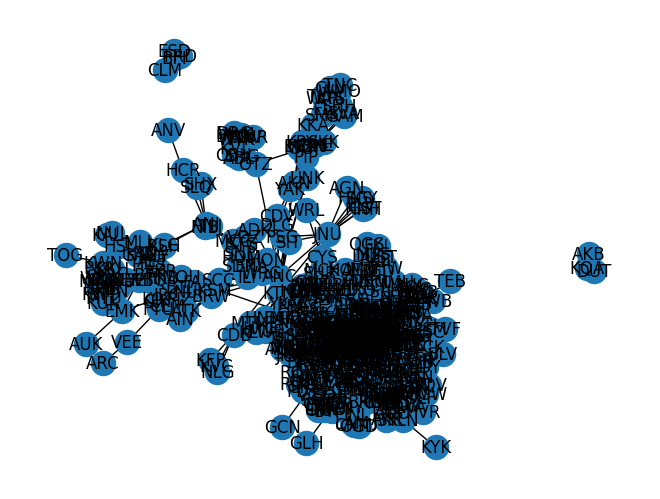

In [4]:
from google.colab import drive
drive.mount('/content/drive')
AIR = nx.read_graphml('/content/drive/MyDrive/Google Drive/Google Drive/Courses/DSC210/Notes/11-networks/openflights_usa.graphml')
nx.draw(AIR, with_labels=True)

## Questions!

- Is there a direct flight between Indianapolis (IND) and Fairbanks, Alaska (FAI)? A direct flight is one with no intermediate stops.
- If I wanted to fly from Indianapolis to Fairbanks, Alaska what would be an itinerary with the fewest number of flights?
- Is it possible to travel from any airport in the US to any other airport in the US, possibly using connecting flights? In other words, does there exist a path in the network between every possible pair of airports?

TypeError: has_path() got an unexpected keyword argument 'length'

In [8]:
print(AIR.has_edge('FAI', 'IND'))

False


In [13]:
try:
    shortest_path = nx.shortest_path(AIR, source='MSP', target='RST')
    print(f"Shortest path from IND to FAI: {shortest_path}")
    print(f"Number of flights: {len(shortest_path) - 1}")
except nx.NetworkXNoPath:
    print("No path found between IND and FAI.")


Shortest path from IND to FAI: ['MSP', 'RST']
Number of flights: 1


In [14]:
print(nx.is_connected(AIR))

False


## Visualizing Graphs

Nodes and edges can contain additional information (weight, etc.). This typically doesn't include position or location (save geographical).

That means we get to choose how to arrange the nodes!

<img src = 'https://drive.google.com/uc?id=1nW2SsYysB6uEay6zDS1Xf_jpCb5CoxVf' width=800 >




In [29]:
nx.layout.__all__

['bipartite_layout',
 'circular_layout',
 'forceatlas2_layout',
 'kamada_kawai_layout',
 'random_layout',
 'rescale_layout',
 'rescale_layout_dict',
 'shell_layout',
 'spring_layout',
 'spectral_layout',
 'planar_layout',
 'fruchterman_reingold_layout',
 'spiral_layout',
 'multipartite_layout',
 'bfs_layout',
 'arf_layout']

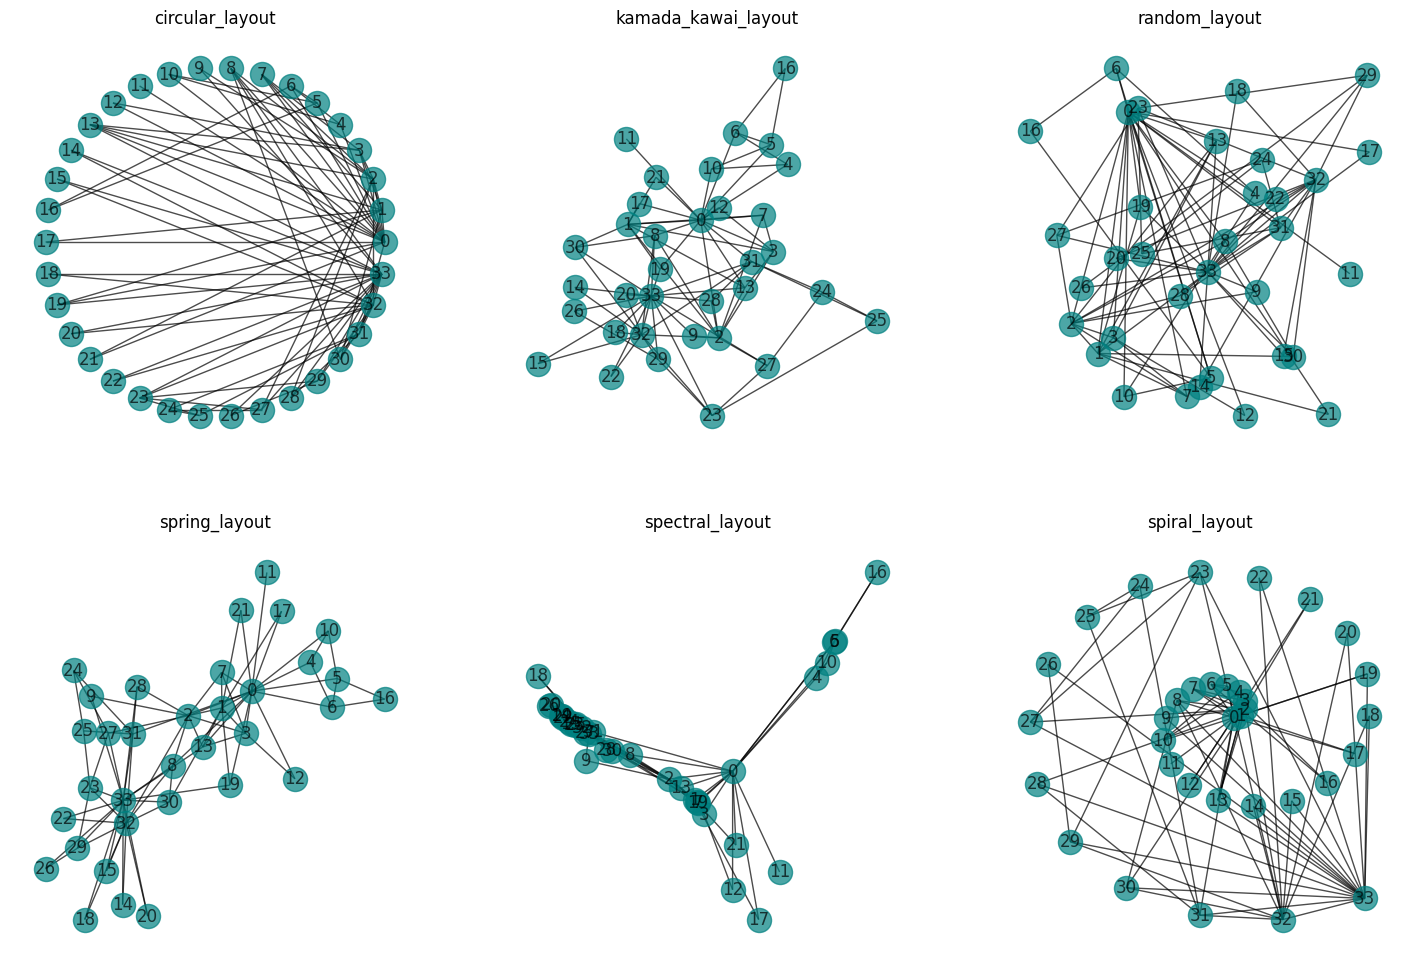

In [33]:
some_layouts = [nx.layout.circular_layout,
               nx.layout.kamada_kawai_layout,
               nx.layout.random_layout,
               nx.layout.fruchterman_reingold_layout,
               nx.layout.spectral_layout,
               nx.layout.spiral_layout,
               ]

G = nx.karate_club_graph()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, func in enumerate(some_layouts):
    pos = func(G)
    x = i // 3
    y = i % 3
    nx.draw(G, with_labels=True, node_color='teal',
           pos=pos, ax=axes[x, y], alpha=0.7)
    axes[x, y].set_title(func.__name__)

plt.show()

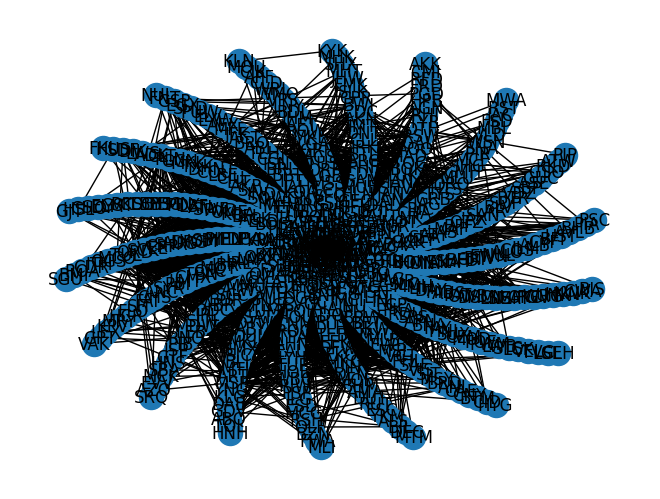

In [37]:
# Flight paths are still too hard to read
pos = nx.spiral_layout(AIR)
nx.draw(AIR, pos, with_labels=True)

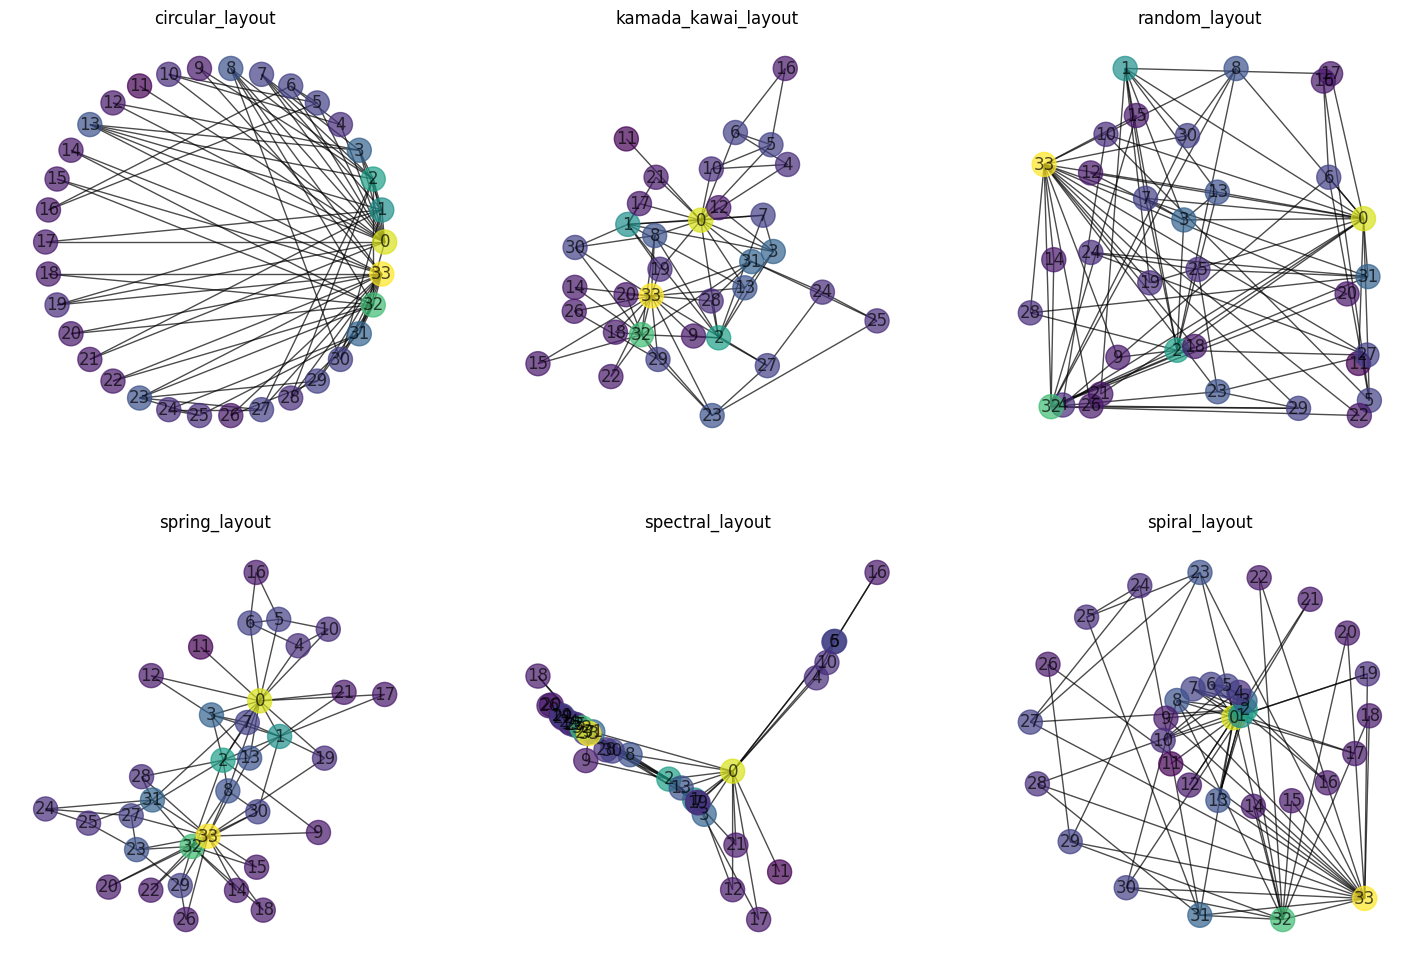

In [38]:
# Add color based on node degree
some_layouts = [nx.layout.circular_layout,
               nx.layout.kamada_kawai_layout,
               nx.layout.random_layout,
               nx.layout.fruchterman_reingold_layout,
               nx.layout.spectral_layout,
               nx.layout.spiral_layout,
               ]

G = nx.karate_club_graph()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, func in enumerate(some_layouts):
    pos = func(G)
    x = i // 3
    y = i % 3
    nx.draw(G, with_labels=True, node_color=[G.degree(n) for n in G.nodes()],
           pos=pos, ax=axes[x, y], alpha=0.7)
    axes[x, y].set_title(func.__name__)

plt.show()

In [44]:
#Interactive Graphs?
#!pip install pyvis
from pyvis.network import Network

# Create a pyvis Network object
net = Network(height = "700px", width = "700px", notebook = True, cdn_resources='remote')

node_sizes = [2 * G.degree(n) for n in G.nodes()]

# Set node sizes and colors
for i, name in enumerate(G.nodes):
    G.nodes[name]['size'] = node_sizes[i]
    G.nodes[name]['color'] = "lightblue" if name == 0 or name == 33 else "crimson"

# Set edge color
for i in G.edges:
    G.edges[i]['color'] = "grey"

net.from_nx(G)
net.save_graph("/content/drive/MyDrive/Google Drive/Google Drive/Courses/DSC210/Notes/11-networks/out1.html")

In [46]:
from pyvis.network import Network

# Create a pyvis Network object
net = Network(height="700px", width="700px", notebook=True, cdn_resources='remote')

# Populate the pyvis network from the AIR networkx graph
net.from_nx(AIR)

# Save the graph to an HTML file in the current directory
net.save_graph("/content/drive/MyDrive/Google Drive/Google Drive/Courses/DSC210/Notes/11-networks/out2.html")


Interactive graph saved as interactive_air_graph.html


In [49]:
from pyvis.network import Network

# Create a pyvis Network object
net = Network(height="700px", width="700px", notebook=True, cdn_resources='remote')

# Populate the pyvis network from the AIR networkx graph
net.from_nx(AIR)
net.show_buttons(filter_=['physics'])

# Save the graph to an HTML file in the current directory
net.save_graph("/content/drive/MyDrive/Google Drive/Google Drive/Courses/DSC210/Notes/11-networks/out3.html")


Example: cat to dog. Ask LLM to create code to determine minimum number of 3 letter words, one letter changed at a time, to turn "cat" to "dog". Using a network model, what is minimum number of steps? 

### Other Visualization Tools

#### Cytoscape (https://cytoscape.org/)
- **Pros:**
  - Many layout and graphical settings.
  - Good export functionality (image, graph, HTML).
  - Good data import functions.
- **Cons:**
  - No live rendering.
  - Possibly more quickly overwhelmed than Gephi and Graphia?

#### Gephi (https://gephi.org/)
- **Pros:**
  - Live rendering.
  - Can handle (relatively) large graphs reasonably well.
  - Many statistical functions.
- **Cons:**
  - Graphically offers fewer options than Cytoscape.

#### Graphia (https://graphia.app/)
- **Pros:**
  - Fast performance
  - 3D option available
- **Cons:**
  - Fewer customization options (for both layout and graphical display)
  - Image export is not very flexible